## Ch7. Time series regression models Forecasting: Principles & Practice (Python Edition) Extracted from: fpppy-07-regression.qmd

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## [Slide 5] Spurious Regression

In [2]:
import statsmodels.api as sm

Check residual autocorrelation

In [3]:
import statsmodels.formula.api as smf
air = pd.read_csv("data/aus_airpassengers.csv")[["Year","Passengers"]]
rice = pd.read_csv("data/guinea_rice.csv")[["Year","Production"]]
spurious_df = air.merge(rice, on="Year")
fitted_model = smf.ols("Passengers ~ Production", data=spurious_df).fit()


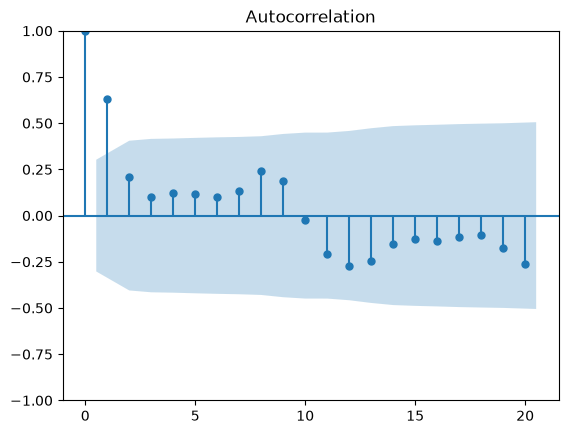

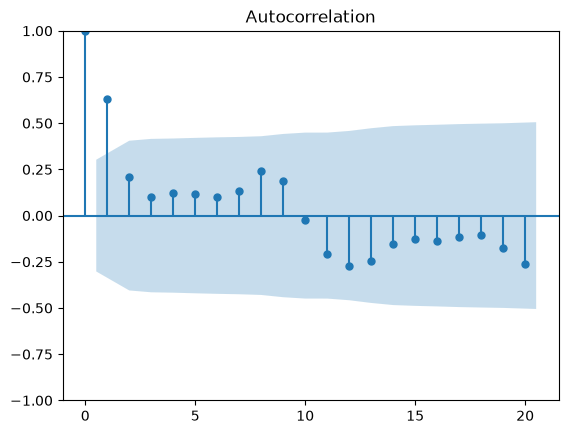

In [4]:
residuals = fitted_model.resid
sm.graphics.tsa.plot_acf(residuals, lags=20)

Formal test

In [5]:
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuals)
print(f"Durbin-Watson: {dw:.4f}")  # ~2 indicates no autocorrelation

Durbin-Watson: 0.4684


## [Slide 8] Fourier Terms for Seasonality

In [6]:
from utilsforecast.feature_engineering import fourier, trend, pipeline
from functools import partial


Add K=3 Fourier pairs for m=52 (weekly data)

In [7]:
df = pd.read_csv("data/us_gasoline.csv", parse_dates=["ds"])
df_feat, _ = pipeline(
    df, features=[partial(fourier, season_length=52, k=3), trend],
    freq="W", h=1,
)


## [Slide 12] Stepwise vs.\ Best Subset Selection

In [8]:
from mlforecast import MLForecast
from sklearn.linear_model import LinearRegression
from utilsforecast.feature_engineering import fourier, trend

Build feature matrix with trend + K Fourier pairs

In [9]:
df = pd.read_csv("data/US_change.csv", parse_dates=["ds"])
df_feat, future_data = pipeline(
    df, features=[partial(fourier, season_length=4, k=2), trend],
    freq="QS-OCT", h=4,
)

mf = MLForecast(
    models={"OLS": LinearRegression()},
    freq="QS-OCT",
    target_transforms=None,
)
mf.fit(df_feat, fitted=True, static_features=[])


MLForecast(models=[OLS], freq=QS-OCT, lag_features=[], date_features=[], num_threads=1)

## [Slide 15] Prediction Intervals for Regression Prediction intervals using PredictionIntervals

In [10]:
from mlforecast.utils import PredictionIntervals

mf.fit(df_feat, fitted=True)
fc = mf.predict(
    h=4,
    X_df=future_data,
    level=[80, 95],
    prediction_intervals=PredictionIntervals(n_windows=10, h=4),
)

ValueError: Income is declared as a static feature but its values change over time. Please set the `static_features` argument to indicate which features are static.
If all of your features are dynamic please set `static_features=[]`.

## [Slide 18] Piecewise Linear Trends

In [11]:
import numpy as np

Create piecewise linear features

In [12]:
tau1 = 2008   # GFC breakpoint
df["t"] = np.arange(1, len(df)+1)
df["t_break1"] = np.maximum(0, df["t"] - tau1)

## [Slide 21] Summary: Regression Modelling Workflow

In [13]:
import statsmodels.formula.api as smf

Full model with trend + quarterly dummies

In [14]:
df["Quarter"] = df["ds"].dt.quarter
for q in [1, 2, 3]:
    df[f"Q{q}"] = (df["Quarter"] == q).astype(int)


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     1.579
Date:                Sun, 20 Sep 2026   Prob (F-statistic):              0.181
Time:                        07:51:56   Log-Likelihood:                -188.23
No. Observations:                 198   AIC:                             386.5
Df Residuals:                     193   BIC:                             402.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.8486      0.120      7.066      0.0

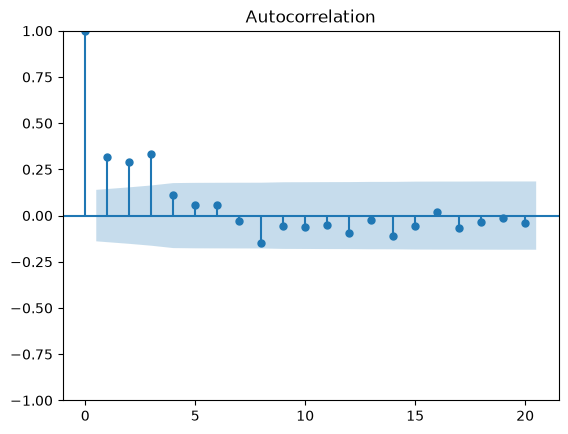

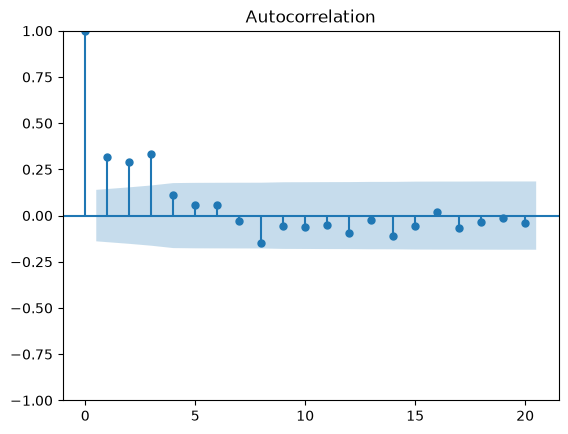

In [15]:
mod = smf.ols("y ~ t + Q('Q1') + Q('Q2') + Q('Q3')", data=df).fit()
print(mod.summary())
sm.graphics.tsa.plot_acf(mod.resid, lags=20)